In [1]:
!pip install numpy matplotlib opencv-python scipy pandas pillow

In [2]:
from google.colab import files

uploaded = files.upload()

Saving hubble.jpg.html to hubble.jpg.html


Downloading the image from the provided URL. This will save the image as `hubble_deep_field.jpg` in your Colab environment.

In [5]:
import requests

image_url = "https://cdn.esahubble.org/archives/images/screen/heic0611b.jpg"
image_filename = "hubble_deep_field.jpg"

try:
    response = requests.get(image_url, stream=True)
    response.raise_for_status() # Raise an exception for HTTP errors

    with open(image_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Image downloaded successfully as {image_filename}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")


Image downloaded successfully as hubble_deep_field.jpg


GALAXY DETECTION REPORT
Detected galaxies: 135
Average size     : 181.04
Largest galaxy   : 1752.50 


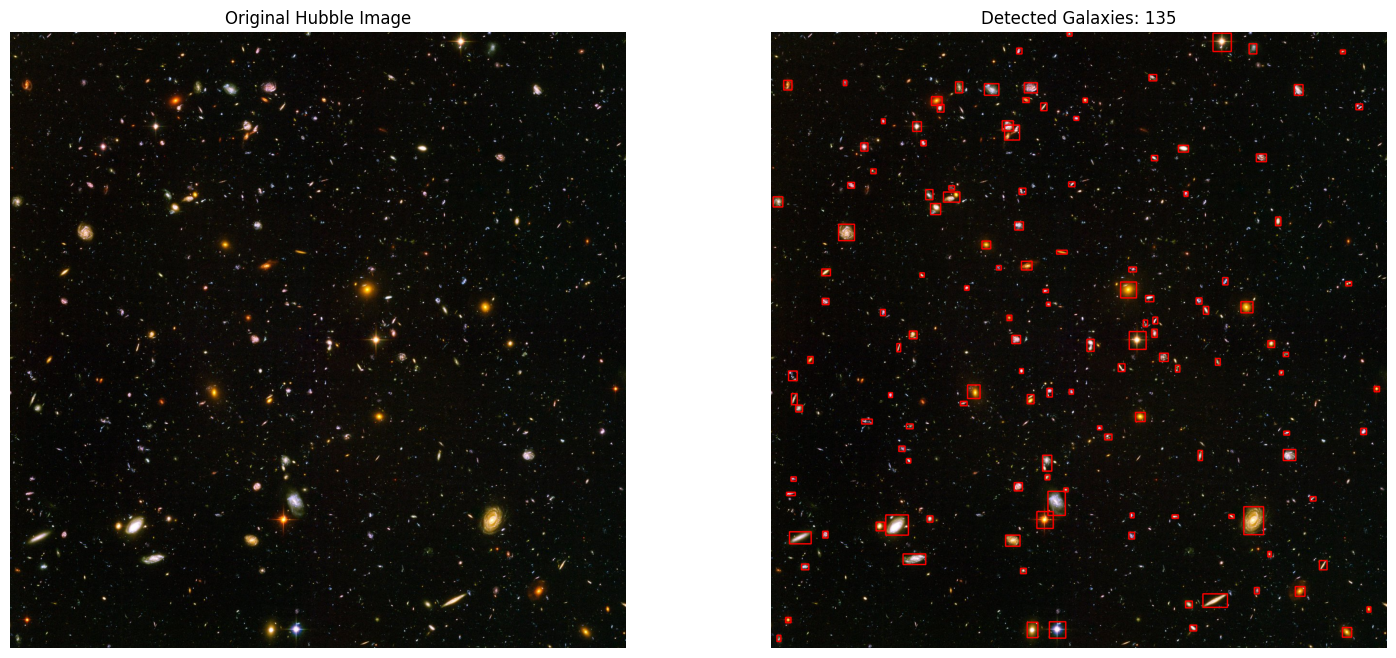

In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD IMAGE
# --------------------------------------------------

image = cv2.imread("hubble_deep_field.jpg")

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# --------------------------------------------------
# GRAYSCALE
# --------------------------------------------------

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

# --------------------------------------------------
# NOISE REDUCTION
# --------------------------------------------------

blur = cv2.GaussianBlur(
    gray,
    (5,5),
    0
)

# --------------------------------------------------
# THRESHOLDING
# --------------------------------------------------

thresh = cv2.threshold(
    blur,
    60,
    255,
    cv2.THRESH_BINARY
)

# --------------------------------------------------
# FIND OBJECTS
# --------------------------------------------------

contours, _ = cv2.findContours(
    thresh[1], # Access the thresholded image from the tuple
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# --------------------------------------------------
# FILTER OBJECTS
# --------------------------------------------------

galaxies = []


output = image_rgb.copy()

for contour in contours:

  area = cv2.contourArea(contour)

  if area > 40:

    x,y,w,h = cv2.boundingRect(contour)

    galaxies.append(area)

    cv2.rectangle(
        output,
        (x,y),
        (x+w,y+h),
        (255,0,0),
        2
    )

# --------------------------------------------------
# STATISTICS
# --------------------------------------------------

count = len(galaxies)

if count > 0:

  avg_size = np.mean(galaxies)

  max_size = np.max(galaxies)

else:

  avg_size = 0

  max_size = 0


print("="*40)
print("GALAXY DETECTION REPORT")
print("="*40)
print(f"Detected galaxies: {count}")
print(f"Average size     : {avg_size:.2f}")
print(f"Largest galaxy   : {max_size:.2f} ")
print("="*40)

# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Hubble Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title(f"Detected Galaxies: {count}")
plt.axis("off")

plt.show()